In [3]:
import pandas as pd

dataset = pd.read_csv('crypto_defi_correlations.csv')
dataset['date'] = pd.to_datetime(dataset['date'])
dataset.head()

,date,symbol,price_spot,volume_usd,open_interest_usd,funding_rate_pct,realized_vol_ann
0,2025-01-03,BTCUSDT,96551.0365,7.802028e+09,1.816893e+10,0.03794,0.61136
1,2025-01-04,BTCUSDT,96153.6360,9.287758e+09,1.790786e+10,-0.75000,0.61136
2,2025-01-05,BTCUSDT,98196.7697,6.649606e+09,1.777108e+10,0.75000,0.61136
3,2025-01-06,BTCUSDT,103132.0572,7.166632e+09,1.826938e+10,0.75000,0.61136
4,2025-01-07,BTCUSDT,102392.8993,7.074853e+09,1.815393e+10,-0.75000,0.61136


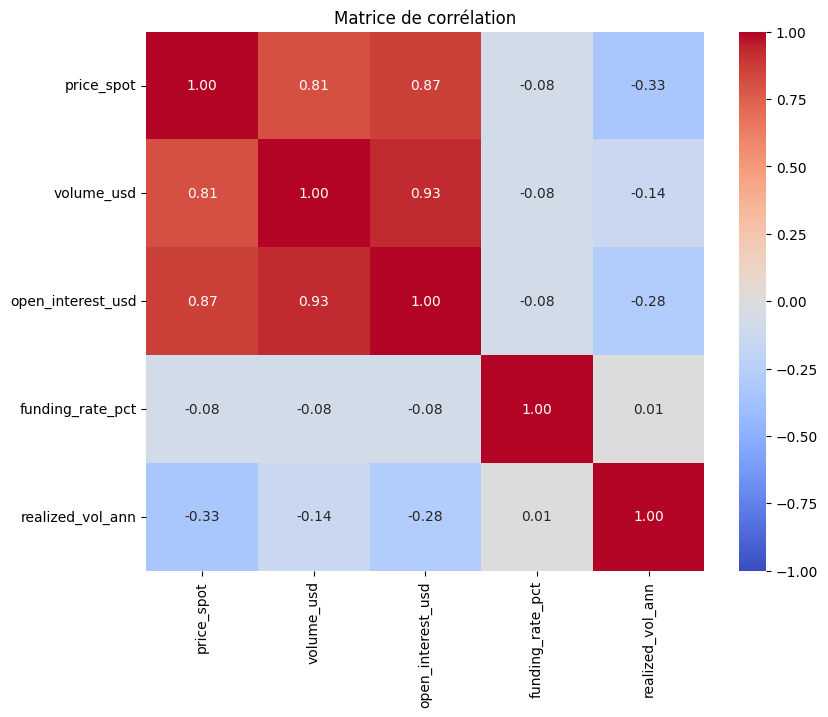

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

vars_analyse = ['price_spot', 'volume_usd', 'open_interest_usd', 'funding_rate_pct', "realized_vol_ann"]

corr_heatmap = dataset[vars_analyse].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_heatmap, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

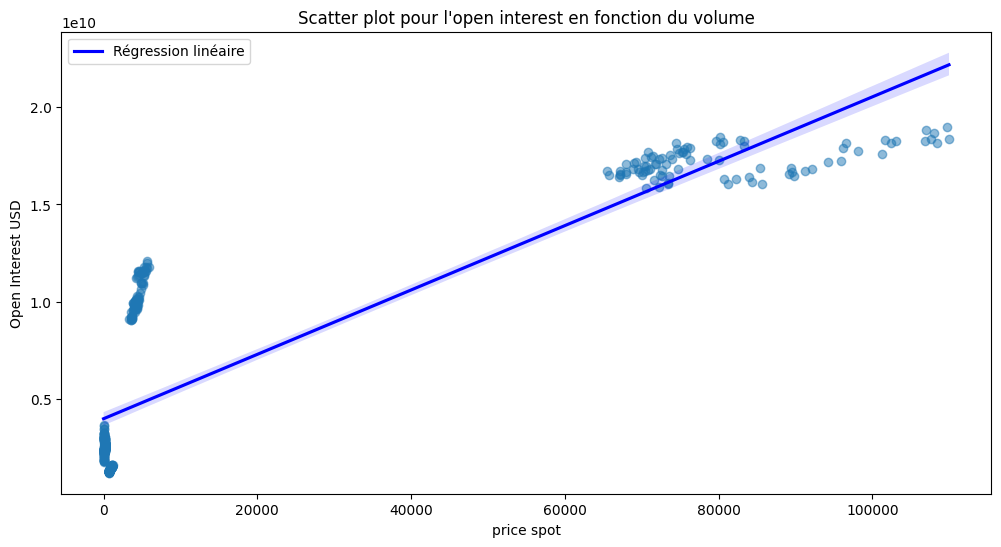

Corrélation entre volume_usd et open_interest_usd : 0.8662520996293628


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(dataset['price_spot'], dataset['open_interest_usd'], alpha=0.5)
sns.regplot(
    x=dataset["price_spot"],
    y=dataset["open_interest_usd"],
    scatter=False,
    color='blue',
    label='Régression linéaire'
)
plt.title("Scatter plot pour l'open interest en fonction du volume")
plt.xlabel("price spot")
plt.ylabel("Open Interest USD")
plt.legend()
plt.show()

print("Corrélation entre volume_usd et open_interest_usd :", dataset['price_spot'].corr(dataset['open_interest_usd']))

In [6]:
"""
Nappe de volatilité implicite Deribit + corrélations
------------------------------------------------------
Dépendances : pip install ccxt pandas numpy scipy matplotlib seaborn
Usage       : python vol_surface_correlations.py
"""

import ccxt
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# 1. RÉCUPÉRATION DES DONNÉES DERIBIT
# ─────────────────────────────────────────

def fetch_vol_surface(underlying="BTC"):
    """Récupère tous les tickers d'options BTC/ETH actifs sur Deribit."""
    exchange = ccxt.deribit()
    exchange.load_markets()

    rows = []
    for symbol, market in exchange.markets.items():
        if not (market["type"] == "option" and market["base"] == underlying):
            continue
        try:
            ticker = exchange.fetch_ticker(symbol)
            info   = ticker.get("info", {})

            iv         = float(info.get("mark_iv", 0) or 0)
            strike     = float(market["strike"])
            expiry     = pd.to_datetime(market["expiryDatetime"])
            option_type = market["optionType"]   # 'call' ou 'put'
            spot       = float(info.get("underlying_price", 0) or 0)
            bid_iv     = float(info.get("bid_iv", 0) or 0)
            ask_iv     = float(info.get("ask_iv", 0) or 0)
            oi         = float(info.get("open_interest", 0) or 0)
            volume     = float(ticker.get("quoteVolume", 0) or 0)
            delta      = float(info.get("greeks", {}).get("delta", 0) or 0)
            vega       = float(info.get("greeks", {}).get("vega", 0) or 0)

            if iv <= 0 or spot <= 0:
                continue

            now = pd.Timestamp.utcnow().tz_localize(None)
            tte_days = max((expiry.tz_localize(None) - now).days, 0)

            moneyness = np.log(strike / spot)   # log-moneyness

            rows.append({
                "symbol":      symbol,
                "underlying":  underlying,
                "expiry":      expiry.date(),
                "tte_days":    tte_days,
                "strike":      strike,
                "spot":        spot,
                "moneyness":   round(moneyness, 4),
                "option_type": option_type,
                "iv":          round(iv, 4),
                "bid_iv":      round(bid_iv, 4),
                "ask_iv":      round(ask_iv, 4),
                "iv_spread":   round(ask_iv - bid_iv, 4),
                "open_interest": oi,
                "volume":      volume,
                "delta":       delta,
                "vega":        vega,
            })
        except Exception:
            continue

    df = pd.DataFrame(rows)
    df = df[df["tte_days"] > 0].copy()
    return df


# ─────────────────────────────────────────
# 2. CHARGEMENT ET NETTOYAGE
# ─────────────────────────────────────────

print("Connexion Deribit…")
df = fetch_vol_surface("BTC")
print(f"  → {len(df)} options récupérées")

# Filtres qualité
df = df[
    (df["iv"] > 5) & (df["iv"] < 500) &
    (df["tte_days"] <= 365) &
    (df["moneyness"].between(-0.8, 0.8))
].copy()
print(f"  → {len(df)} options après filtrage\n")

df.to_csv("vol_surface_raw.csv", index=False)
print("CSV sauvegardé : vol_surface_raw.csv")


# ─────────────────────────────────────────
# 3. NAPPE DE VOLATILITÉ (SURFACE PLOT)
# ─────────────────────────────────────────

def plot_vol_surface(df):
    from scipy.interpolate import griddata

    x = df["moneyness"].values
    y = df["tte_days"].values
    z = df["iv"].values

    xi = np.linspace(x.min(), x.max(), 60)
    yi = np.linspace(y.min(), y.max(), 60)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method="cubic")

    fig = plt.figure(figsize=(12, 7))
    ax  = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(Xi, Yi, Zi, cmap="RdYlGn_r", alpha=0.85, edgecolor="none")
    ax.set_xlabel("Log-Moneyness  ln(K/S)", labelpad=10)
    ax.set_ylabel("Maturité (jours)", labelpad=10)
    ax.set_zlabel("IV (%)", labelpad=10)
    ax.set_title("Nappe de Volatilité Implicite — BTC Options (Deribit)", fontsize=13, pad=15)
    fig.colorbar(surf, ax=ax, shrink=0.5, label="IV (%)")
    plt.tight_layout()
    plt.savefig("vol_surface_3d.png", dpi=150)
    plt.close()
    print("Plot sauvegardé : vol_surface_3d.png")

plot_vol_surface(df)


# ─────────────────────────────────────────
# 4. CORRÉLATIONS
# ─────────────────────────────────────────

vars_corr = {
    "iv":           "IV (%)",
    "moneyness":    "Log-Moneyness",
    "tte_days":     "Maturité (j)",
    "open_interest":"Open Interest",
    "volume":       "Volume",
    "iv_spread":    "Spread IV (ask-bid)",
    "vega":         "Vega",
    "delta":        "Delta",
}

corr_df = df[list(vars_corr.keys())].dropna()

# ── 4a. Heatmap Pearson ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, method, title in zip(
    axes,
    ["pearson", "spearman"],
    ["Corrélation de Pearson (linéaire)", "Corrélation de Spearman (rang)"]
):
    mat = corr_df.corr(method=method).rename(columns=vars_corr, index=vars_corr)
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(
        mat, ax=ax, mask=mask,
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    ax.set_title(title, fontsize=12, pad=10)

plt.suptitle("Corrélations — Nappe de Volatilité BTC (Deribit)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("correlations_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("Plot sauvegardé : correlations_heatmap.png")


# ── 4b. Scatterplots des paires clés ─────
pairs = [
    ("moneyness",    "iv",           "Skew : Log-Moneyness vs IV"),
    ("tte_days",     "iv",           "Term Structure : Maturité vs IV"),
    ("open_interest","iv",           "OI vs IV"),
    ("volume",       "iv",           "Volume vs IV"),
    ("iv_spread",    "iv",           "Spread bid/ask vs IV"),
    ("tte_days",     "open_interest","Maturité vs Open Interest"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (xvar, yvar, title) in zip(axes, pairs):
    sub = corr_df[[xvar, yvar]].dropna()
    r_p, p_p = pearsonr(sub[xvar], sub[yvar])
    r_s, p_s = spearmanr(sub[xvar], sub[yvar])

    color = "steelblue" if yvar == "iv" else "coral"
    ax.scatter(sub[xvar], sub[yvar], alpha=0.35, s=12, color=color)

    # Ligne de tendance
    z = np.polyfit(sub[xvar], sub[yvar], 1)
    xline = np.linspace(sub[xvar].min(), sub[xvar].max(), 100)
    ax.plot(xline, np.polyval(z, xline), "r-", lw=1.5, alpha=0.8)

    ax.set_xlabel(vars_corr.get(xvar, xvar), fontsize=9)
    ax.set_ylabel(vars_corr.get(yvar, yvar), fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.text(
        0.04, 0.93,
        f"r={r_p:.2f} (p={p_p:.3f})\nρ={r_s:.2f} (p={p_s:.3f})",
        transform=ax.transAxes, fontsize=8,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

plt.suptitle("Scatterplots — Vol Surface BTC (Deribit)", fontsize=13)
plt.tight_layout()
plt.savefig("correlations_scatter.png", dpi=150, bbox_inches="tight")
plt.close()
print("Plot sauvegardé : correlations_scatter.png")


# ── 4c. Tableau de résultats ─────────────
print("\n── Résultats corrélations avec IV ──")
results = []
for var in ["moneyness","tte_days","open_interest","volume","iv_spread","vega","delta"]:
    sub = corr_df[["iv", var]].dropna()
    r_p, p_p = pearsonr(sub["iv"], sub[var])
    r_s, p_s = spearmanr(sub["iv"], sub[var])
    results.append({
        "Variable":   vars_corr.get(var, var),
        "Pearson r":  round(r_p, 3),
        "p-val (P)":  round(p_p, 4),
        "Spearman ρ": round(r_s, 3),
        "p-val (S)":  round(p_s, 4),
        "Sig. (5%)":  "✓" if p_p < 0.05 else "✗",
    })

res_df = pd.DataFrame(results)
res_df.to_csv("correlation_results.csv", index=False)
print(res_df.to_string(index=False))
print("\nCSV sauvegardé : correlation_results.csv")
print("\nTerminé ✓")

Connexion Deribit…


KeyboardInterrupt: 